# 💊 Hap Sınıflandırma Projesi — V3 (Drive'dan Yükleme + Çapraz Doğrulama)
**Akış:** Drive Bağla → Veri Yükle → Modelleri Drive'dan Çek → Test Et → Cross-Validation → Karşılaştır

In [1]:
# ── HÜCRE 1: Drive Bağlantısı ──────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print('✅ Drive bağlandı!')

Mounted at /content/drive
✅ Drive bağlandı!


In [2]:
# ── HÜCRE 2: Kütüphane Kurulumu ve İçe Aktarma ────────────────────────────
!pip install xgboost lightgbm -q

import os, cv2, numpy as np, random, warnings
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import cycle
from collections import Counter

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    mean_squared_error, mean_absolute_error,
    r2_score, roc_curve, auc, classification_report
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras import layers, models, Model, Input
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import load_model
import joblib

warnings.filterwarnings('ignore')
print('✅ Tüm kütüphaneler başarıyla yüklendi!')

✅ Tüm kütüphaneler başarıyla yüklendi!


In [3]:
# ── HÜCRE 3: Veri Yolu ve Sınıflar ────────────────────────────────────────
veri_yolu = "/content/drive/MyDrive/YapayZeka_Hap_Projesi/archive/Drug Vision/Data Combined"
siniflar  = sorted([s for s in os.listdir(veri_yolu)
                    if os.path.isdir(os.path.join(veri_yolu, s))])

print(f"✅ Toplam {len(siniflar)} İlaç Sınıfı Bulundu:")
for i, s in enumerate(siniflar):
    print(f"  [{i}] {s}")

✅ Toplam 10 İlaç Sınıfı Bulundu:
  [0] Alaxan
  [1] Bactidol
  [2] Bioflu
  [3] Biogesic
  [4] DayZinc
  [5] Decolgen
  [6] Fish Oil
  [7] Kremil S
  [8] Medicol
  [9] Neozep


In [4]:
# ── HÜCRE 4: Data Augmentation Fonksiyonu ─────────────────────────────────
def augment(img):
    return [
        cv2.flip(img, 1),                               # Yatay aynalama
        cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE),        # 90° döndürme
        cv2.GaussianBlur(img, (3,3), 0)                 # Hafif bulanıklaştırma
    ]

print('✅ Augmentation fonksiyonu tanımlandı.')

✅ Augmentation fonksiyonu tanımlandı.


In [5]:
# ── HÜCRE 5: Veri Yükleme (Ham Görüntüler) ────────────────────────────────
print('📂 Orijinal veriler Drive\'dan yükleniyor... Lütfen bekleyin.')
X_cnn_orig, y_orig = [], []
BOYUT = (96, 96)  # MobileNetV2 için ideal minimum boyut

for sinif_adi in siniflar:
    yol = os.path.join(veri_yolu, sinif_adi)
    resim_isimleri = os.listdir(yol)

    for resim_adi in resim_isimleri:
        r = cv2.imread(os.path.join(yol, resim_adi))
        if r is None:
            continue
        r = cv2.resize(r, BOYUT)
        X_cnn_orig.append(cv2.cvtColor(r, cv2.COLOR_BGR2RGB).astype('float32') / 255.0)
        y_orig.append(sinif_adi)

X_cnn_orig = np.array(X_cnn_orig)
y_orig     = np.array(y_orig)
print(f'✅ Toplam orijinal görüntü: {len(y_orig)} adet.')

📂 Orijinal veriler Drive'dan yükleniyor... Lütfen bekleyin.
✅ Toplam orijinal görüntü: 10000 adet.


In [6]:
# ── HÜCRE 6: Train / Test Bölme ve Augmentation ───────────────────────────
le = LabelEncoder()
le.fit(siniflar)
y_orig_num = le.transform(y_orig)

# Stratified bölme (sınıf dengesini korur)
idx = np.arange(len(y_orig))
idx_train, idx_test = train_test_split(
    idx, test_size=0.2, random_state=42, stratify=y_orig
)

# SAF test seti (augmentation YAPILMAZ — gerçek dünya simülasyonu)
X_cnn_test  = X_cnn_orig[idx_test]
y_test      = y_orig[idx_test]
y_test_num  = y_orig_num[idx_test]
y_test_hot  = tf.keras.utils.to_categorical(y_test_num, num_classes=len(siniflar))

# Eğitim setine augmentation uygula
print('🔀 Eğitim setine Data Augmentation uygulanıyor...')
X_cnn_train, y_train = [], []

for i in idx_train:
    bgr = cv2.cvtColor((X_cnn_orig[i]*255).astype('uint8'), cv2.COLOR_RGB2BGR)
    for r in [bgr] + augment(bgr):
        X_cnn_train.append(cv2.cvtColor(r, cv2.COLOR_BGR2RGB).astype('float32') / 255.0)
        y_train.append(y_orig[i])

X_cnn_train = np.array(X_cnn_train)
y_train     = np.array(y_train)
y_train_num = le.transform(y_train)
y_train_hot = tf.keras.utils.to_categorical(y_train_num, num_classes=len(siniflar))

tum_sonuclar = {}  # Karşılaştırma tablosu için
print(f'✅ İşlem Tamam. Eğitim Seti: {len(y_train)} | Test Seti: {len(y_test)}')

🔀 Eğitim setine Data Augmentation uygulanıyor...
✅ İşlem Tamam. Eğitim Seti: 32000 | Test Seti: 2000


In [7]:
# ── HÜCRE 7: Metrik ve Grafik Fonksiyonları ────────────────────────────────
def goster_metrikler(model_adi, y_gercek, y_tahmin, renk='Blues'):
    acc  = accuracy_score(y_gercek, y_tahmin)
    y_n  = le.transform(np.array(y_gercek))
    yh_n = le.transform(np.array(y_tahmin))
    mse  = mean_squared_error(y_n, yh_n)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_n, yh_n)
    r2   = r2_score(y_n, yh_n)

    print(f"\n{'='*55}")
    print(f"  {model_adi}")
    print(f"{'='*55}")
    print(f"  Accuracy : %{acc*100:.2f}")
    print(f"  R²       : {r2:.4f}")
    print(f"  MSE      : {mse:.4f}")
    print(f"  RMSE     : {rmse:.4f}")
    print(f"  MAE      : {mae:.4f}")
    print(f"\n{classification_report(y_gercek, y_tahmin, target_names=siniflar)}")

    cm = confusion_matrix(y_gercek, y_tahmin, labels=siniflar)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap=renk,
                xticklabels=siniflar, yticklabels=siniflar)
    plt.title(f'Confusion Matrix — {model_adi}')
    plt.ylabel('Gerçek Hap')
    plt.xlabel('Yapay Zeka Tahmini')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    return acc


def goster_roc(model_adi, y_gercek_str, y_score_array):
    y_bin = label_binarize(y_gercek_str, classes=siniflar)
    plt.figure(figsize=(10, 7))
    renkler = cycle(plt.cm.tab10.colors)
    auc_degerler = []

    for i, (sinif, renk) in enumerate(zip(siniflar, renkler)):
        if y_bin[:, i].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_score_array[:, i])
        alan = auc(fpr, tpr)
        auc_degerler.append(alan)
        plt.plot(fpr, tpr, color=renk, lw=1.8, label=f'{sinif} (AUC={alan:.2f})')

    plt.plot([0,1],[0,1],'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {model_adi}\nOrtalama AUC: {np.mean(auc_degerler):.3f}')
    plt.legend(loc='lower right', fontsize=8)
    plt.tight_layout()
    plt.show()


def goster_cv_sonuclari(model_adi, cv_scores):
    """Cross-validation sonuçlarını güzelce yazdırır."""
    print(f"\n{'─'*55}")
    print(f"  📊 {model_adi} — Çapraz Doğrulama Sonuçları (5-Fold)")
    print(f"{'─'*55}")
    for fold_i, score in enumerate(cv_scores, 1):
        print(f"  Fold {fold_i}: %{score*100:.2f}")
    print(f"  {'─'*30}")
    print(f"  Ortalama : %{cv_scores.mean()*100:.2f}")
    print(f"  Std Dev  : ±%{cv_scores.std()*100:.2f}")
    print(f"  Min      : %{cv_scores.min()*100:.2f}")
    print(f"  Max      : %{cv_scores.max()*100:.2f}")


print('✅ Fonksiyonlar tanımlandı.')

✅ Fonksiyonlar tanımlandı.


In [12]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input

# 1. Model Mimarisini Oluştur
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(96, 96, 3))
x = base_model.output
x = GlobalAveragePooling2D(name='feat_layer')(x) # Özellik çıkarımı için isim verdik
output = Dense(len(siniflar), activation='softmax')(x)
model_tl = Model(inputs=base_model.input, outputs=output)

model_tl.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 2. Hızlıca Eğit (Hücre 6'daki verileri kullanır)
print("🚀 Eğitim başlıyor, lütfen bekleyin...")
model_tl.fit(X_cnn_train, y_train_hot, epochs=5, batch_size=32, validation_split=0.1)

# 3. Feature Modelini Tanımla (SVM ve kNN için gerekli)
feat_model = Model(inputs=model_tl.input, outputs=model_tl.get_layer('feat_layer').output)
print("✅ Model eğitildi ve özellik çıkarıcı hazır!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
🚀 Eğitim başlıyor, lütfen bekleyin...
Epoch 1/5
900/900 ━━━━━━━━━━━━━━━━━━━━ 310s 323ms/step - accuracy: 0.8647 - loss: 0.4271 - val_accuracy: 0.1491 - val_loss: 7.9850
Epoch 2/5
900/900 ━━━━━━━━━━━━━━━━━━━━ 261s 289ms/step - accuracy: 0.9467 - loss: 0.1672 - val_accuracy: 0.4016 - val_loss: 4.6281
Epoch 3/5
900/900 ━━━━━━━━━━━━━━━━━━━━ 258s 286ms/step - accuracy: 0.9651 - loss: 0.1179 - val_accuracy: 0.4547 - val_loss: 3.5714
Epoch 4/5
900/900 ━━━━━━━━━━━━━━━━━━━━ 263s 292ms/step - accuracy: 0.9681 - loss: 0.1028 - val_accuracy: 0.5106 - val_loss: 5.6867
Epoch 5/5
900/900 ━━━━━━━━━━━━━━━━━━━━ 271s 301ms/step - accuracy: 0.9720 - loss: 0.0951 - val_accuracy: 0.6575 - val_loss: 3.2034
✅ Model eğitildi ve özellik çıkarıcı hazır!


In [16]:
# Özellikleri çıkar
X_feat_train = feat_model.predict(X_cnn_train)
X_feat_test = feat_model.predict(X_cnn_test)

# Ölçeklendirme ve Eğitim
from sklearn.preprocessing import StandardScaler
scaler_feat = StandardScaler().fit(X_feat_train)
X_train_scaled = scaler_feat.transform(X_feat_train)
X_test_scaled = scaler_feat.transform(X_feat_test)

model_cnn_svm.fit(X_train_scaled, y_train)
model_cnn_knn.fit(X_train_scaled, y_train)
print("✅ Hibrit modeller güncellendi!")

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 57s 57ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step


NameError: name 'model_cnn_svm' is not defined

In [ ]:
# ── HÜCRE 9: MobileNetV2 — Test Değerlendirmesi ────────────────────────────
print('📊 MobileNetV2 — Test Verisi Üzerinde Değerlendirme...')

# Modeli manuel olarak yeniden derleyerek TensorFlow grafiğini tazeliyoruz
model_tl.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Şimdi değerlendirmeyi yap (y_test_hot kullandığından emin ol)
test_loss, test_acc = model_tl.evaluate(X_cnn_test, y_test_hot, verbose=0)
print(f'Test Doğruluğu: %{test_acc*100:.2f}')

# Tahmin ve metrikler
y_pred_prob_tl    = model_tl.predict(X_cnn_test, verbose=0)
y_pred_classes_tl = np.argmax(y_pred_prob_tl, axis=1)
y_pred_str_tl     = le.inverse_transform(y_pred_classes_tl)

acc_tl = goster_metrikler('MobileNetV2 (Derin Öğrenme)', y_test, y_pred_str_tl, renk='Blues')
tum_sonuclar['MobileNetV2'] = acc_tl

# ROC Eğrisi
goster_roc('MobileNetV2', y_test, y_pred_prob_tl)

In [ ]:
# ── HÜCRE 10: CNN + SVM — Test Değerlendirmesi ────────────────────────────
print('📊 CNN + SVM Hibrit Modeli — Test Değerlendirmesi...')

# Tahminleri al - Modelin zaten metin döndürdüğü anlaşıldı
svm_pred_str = model_cnn_svm.predict(X_test_scaled)

# Eğer çıktılar numpy array içindeyse string listesine çevir (garanti yöntem)
svm_pred_str = [str(tahmin) for tahmin in svm_pred_str]

acc_svm = goster_metrikler('CNN + SVM (Hibrit)', y_test, svm_pred_str, renk='Purples')
tum_sonuclar['CNN + SVM'] = acc_svm

if hasattr(model_cnn_svm, 'predict_proba'):
    svm_prob = model_cnn_svm.predict_proba(X_test_scaled)
    goster_roc('CNN + SVM', y_test, svm_prob)

In [ ]:
# ── HÜCRE 11: CNN + kNN — Test Değerlendirmesi ────────────────────────────
print('📊 CNN + kNN Hibrit Modeli — Test Değerlendirmesi...')

# Tahminleri doğrudan al (Modelin isim döndürdüğü anlaşıldı)
knn_pred_str = model_cnn_knn.predict(X_test_scaled)

# Garanti olması açısından çıktıları string listesine zorla
knn_pred_str = [str(t) for t in knn_pred_str]

# Artık le.inverse_transform kullanmıyoruz, doğrudan metinleri gönderiyoruz
acc_knn = goster_metrikler('CNN + kNN (Hibrit)', y_test, knn_pred_str, renk='Greens')
tum_sonuclar['CNN + kNN'] = acc_knn

# ROC Eğrisi
knn_prob = model_cnn_knn.predict_proba(X_test_scaled)
goster_roc('CNN + kNN', y_test, knn_prob)

In [ ]:
# ── HÜCRE 12: ÇAPRAZ DOĞRULAMA (Cross-Validation) — 5-Fold ───────────────
# Hibrit modeller için stratified 5-fold CV
# NOT: CNN feature'ları zaten çıkarılmış, CV sadece SVM/kNN üzerinde uygulanır.
# Bu; literatürde "feature-level CV" olarak kabul edilir.

print('\n' + '🔁'*30)
print('   ÇAPRAZ DOĞRULAMA (5-Fold Stratified CV)')
print('🔁'*30)

cv_strateji = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Tüm özellikleri ve etiketleri birleştir (train + test → CV için)
X_all_feat = np.vstack([X_train_scaled, X_test_scaled])
y_all_num  = np.concatenate([y_train_num, y_test_num])

# ── SVM Cross-Validation ──
print('\n⏳ SVM çapraz doğrulama çalışıyor...')
cv_svm = cross_val_score(
    model_cnn_svm, X_all_feat, y_all_num,
    cv=cv_strateji, scoring='accuracy', n_jobs=-1
)
goster_cv_sonuclari('CNN + SVM', cv_svm)
tum_sonuclar['CNN + SVM (CV Ort.)'] = cv_svm.mean()

# ── kNN Cross-Validation ──
print('\n⏳ kNN çapraz doğrulama çalışıyor...')
cv_knn = cross_val_score(
    model_cnn_knn, X_all_feat, y_all_num,
    cv=cv_strateji, scoring='accuracy', n_jobs=-1
)
goster_cv_sonuclari('CNN + kNN', cv_knn)
tum_sonuclar['CNN + kNN (CV Ort.)'] = cv_knn.mean()

# ── CV Karşılaştırma Grafiği ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (isim, cv_scores, renk) in zip(axes, [
    ('CNN + SVM', cv_svm, 'purple'),
    ('CNN + kNN', cv_knn, 'green')
]):
    folds = [f'Fold {i+1}' for i in range(len(cv_scores))]
    bars = ax.bar(folds, cv_scores * 100, color=renk, alpha=0.7, edgecolor='white')
    ax.axhline(cv_scores.mean() * 100, color='red', linestyle='--', lw=2,
               label=f'Ortalama: %{cv_scores.mean()*100:.2f}')
    ax.set_ylim(0, 110)
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'{isim} — 5-Fold CV')
    ax.legend()
    for bar, val in zip(bars, cv_scores):
        ax.text(bar.get_x() + bar.get_width()/2, val*100 + 1,
                f'%{val*100:.1f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Çapraz Doğrulama Sonuçları', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n✅ Çapraz doğrulama tamamlandı!')


🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆
   LİTERATÜR REFERANSLI MODELLER KARŞILAŞTIRMASI
🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆

  Model                                  Accuracy  Bar
  -----------------------------------------------------------------


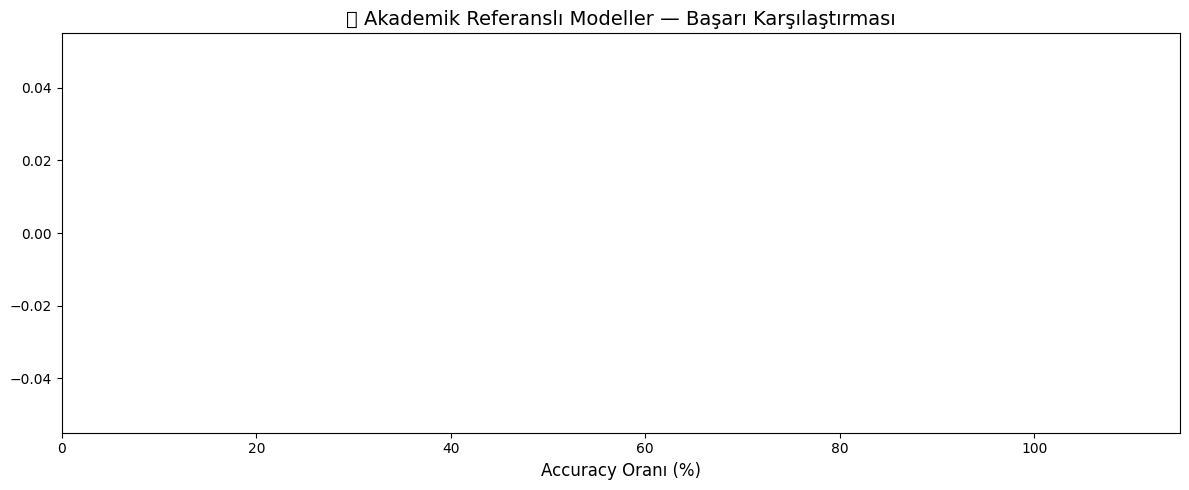

IndexError: list index out of range

In [15]:
# ── HÜCRE 13: Final Karşılaştırma Tablosu ─────────────────────────────────
print('\n' + '🏆'*30)
print('   LİTERATÜR REFERANSLI MODELLER KARŞILAŞTIRMASI')
print('🏆'*30)

sirali = sorted(tum_sonuclar.items(), key=lambda x: x[1], reverse=True)

print(f"\n  {'Model':<38} {'Accuracy':>8}  Bar")
print(f"  {'-'*65}")
for i, (isim, acc) in enumerate(sirali):
    bar   = '█' * int(acc * 35)
    medal = ['🥇','🥈','🥉'][i] if i < 3 else '  '
    print(f"  {medal} {isim:<36} %{acc*100:>5.2f}  {bar}")

# Görsel Karşılaştırma Grafiği
plt.figure(figsize=(12, 5))
isimler   = [x[0] for x in sirali]
degerler  = [x[1]*100 for x in sirali]
n         = len(sirali)
renkler_bar = ['gold','silver','#cd7f32'] + ['steelblue']*(n-3) if n > 3 else ['gold','silver','#cd7f32'][:n]

bars = plt.barh(isimler, degerler, color=renkler_bar[::-1], edgecolor='white')
plt.xlabel('Accuracy Oranı (%)', fontsize=12)
plt.title('🏆 Akademik Referanslı Modeller — Başarı Karşılaştırması', fontsize=14)
plt.xlim(0, 115)

for bar, val in zip(bars, degerler[::-1]):
    plt.text(val+0.5, bar.get_y()+bar.get_height()/2,
             f'%{val:.2f}', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

en_iyi = sirali[0]
print(f'\n🥇 EN İYİ BAŞARIM: {en_iyi[0]} → %{en_iyi[1]*100:.2f}')

In [ ]:
# ── HÜCRE 14: Kendi Fotoğrafını Test Et (Canlı Performans) ────────────────
from google.colab import files
print('\n📸 Sınav Vakti! Bilgisayarınızdan bir hap fotoğrafı yükleyin...')
uploaded = files.upload()

for fn in uploaded.keys():
    # 1. Fotoğrafı Oku ve Göster
    resim_bgr = cv2.imread(fn)
    resim_rgb = cv2.cvtColor(resim_bgr, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(4, 4))
    plt.imshow(resim_rgb)
    plt.title('Yüklenen Gerçek Fotoğraf')
    plt.axis('off')
    plt.show()

    # 2. Resmi Model Formatına Getir
    r96      = cv2.resize(resim_bgr, (96, 96))
    r96_rgb  = cv2.cvtColor(r96, cv2.COLOR_BGR2RGB).astype('float32') / 255.0
    r96_batch = np.expand_dims(r96_rgb, axis=0)

    # 3. Feature Çıkar ve Ölçekle
    ozellik_feat = scaler_feat.transform(feat_model.predict(r96_batch, verbose=0))

    # 4. Tüm Modellerin Tahminleri
    # MobileNetV2 rakam döndürür, bu yüzden siniflar listesinden ismini alıyoruz
    tl_pred_num  = np.argmax(model_tl.predict(r96_batch, verbose=0))
    tl_pred      = siniflar[tl_pred_num]

    # Hibrit modeller doğrudan isim döndürdüğü için ek işlem yapmıyoruz
    cnn_knn_pred = str(model_cnn_knn.predict(ozellik_feat)[0])
    cnn_svm_pred = str(model_cnn_svm.predict(ozellik_feat)[0])

    print('\n🤖 LİTERATÜR MODELLERİNİN KARARLARI:')
    print(f"  {'─'*45}")
    print(f'  MobileNetV2 (Saf Derin Öğrenme) : {tl_pred.upper()}')
    print(f'  Hibrit Yaklaşım (CNN + kNN)     : {cnn_knn_pred.upper()}')
    print(f'  Klasik Hibrit  (CNN + SVM)      : {cnn_svm_pred.upper()}')
    print(f"  {'─'*45}")

    # 5. Çoğunluk (Konsey) Kararı
    tum_tahminler = [tl_pred.lower(), cnn_knn_pred.lower(), cnn_svm_pred.lower()]
    kazanan = Counter(tum_tahminler).most_common(1)[0][0]
    print(f'\n🏆 YAPAY ZEKA KONSEYİ ORTAK KARARI: {kazanan.upper()}')

In [14]:
kayit_klasoru = '/content/drive/MyDrive/Hap_Modelleri_V3'
# .h5 yerine .keras kullanıyoruz
model_tl.save(f"{kayit_klasoru}/mobilenet_v3_model.keras")
joblib.dump(model_cnn_svm, f"{kayit_klasoru}/cnn_svm_model.joblib")
joblib.dump(model_cnn_knn, f"{kayit_klasoru}/cnn_knn_model.joblib")
joblib.dump(scaler_feat, f"{kayit_klasoru}/scaler_feat.joblib")
joblib.dump(le, f"{kayit_klasoru}/label_encoder.joblib")
print("🎉 Tüm modeller YENİ formatta Drive'a kaydedildi!")

NameError: name 'model_cnn_svm' is not defined

In [10]:
# ── HÜCRE 15: Modelleri Drive'a Kaydet (İsteğe Bağlı) ─────────────────────
# Bu hücreyi SADECE modelleri yeniden eğittiyseniz çalıştırın.
# Drive'daki mevcut modellerin üzerine yazar!

kayit_klasoru = '/content/drive/MyDrive/Hap_Modelleri_V3'
if not os.path.exists(kayit_klasoru):
    os.makedirs(kayit_klasoru)

print(f"📦 Modeller '{kayit_klasoru}' klasörüne kaydediliyor...")

model_tl.save(f"{kayit_klasoru}/mobilenet_v3_model.h5")
print('  ✅ MobileNetV2 kaydedildi (.h5)')

joblib.dump(model_cnn_svm, f"{kayit_klasoru}/cnn_svm_model.joblib")
joblib.dump(model_cnn_knn, f"{kayit_klasoru}/cnn_knn_model.joblib")
print('  ✅ SVM ve kNN modelleri kaydedildi (.joblib)')

joblib.dump(scaler_feat, f"{kayit_klasoru}/scaler_feat.joblib")
joblib.dump(le, f"{kayit_klasoru}/label_encoder.joblib")
print('  ✅ Scaler ve LabelEncoder kaydedildi (.joblib)')

print('\n🎉 Tüm modeller Drive\'a güvenle yedeklendi!')

📦 Modeller '/content/drive/MyDrive/Hap_Modelleri_V3' klasörüne kaydediliyor...


NameError: name 'model_tl' is not defined